In [ ]:
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

In [ ]:
# === Conexion Athena estilo Cruce + fallback awswrangler ===
import os
import re
import sys
from pathlib import Path

import boto3
import awswrangler as wr
import pandas as pd

EXPLICIT_CREDENTIALS_SH = Path(r"c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test/credentials.sh")


def _find_dir_with_athena_client(preferred_dir: Path | None = None) -> Path | None:
    cwd = Path.cwd().resolve()
    search_roots = []

    if preferred_dir is not None:
        search_roots.append(preferred_dir)

    search_roots.extend([cwd, *cwd.parents])

    home = Path.home()
    search_roots.extend([
        home / "OneDrive - Interbank" / "conexion_aws" / "athena_conection_test",
        Path("c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test"),
    ])

    visited = set()
    for root in search_roots:
        if root in visited:
            continue
        visited.add(root)

        if not root.exists():
            continue
        if (root / "athena_client.py").exists() and (root / "athena_config.json").exists():
            return root
    return None


def _load_credentials_from_sh(sh_path: Path) -> list[str]:
    if not sh_path.exists():
        return []

    loaded_keys: list[str] = []
    pattern = re.compile(r'^\s*export\s+([A-Za-z_][A-Za-z0-9_]*)=(.*)$')

    for line in sh_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = pattern.match(line)
        if not match:
            continue

        key, raw_val = match.groups()
        value = raw_val.strip().strip('"').strip("'")
        if key and value:
            os.environ[key] = value
            loaded_keys.append(key)

    return loaded_keys


def _build_session(aws_region: str) -> boto3.Session:
    aws_profile = os.getenv("AWS_PROFILE")
    if aws_profile:
        return boto3.Session(profile_name=aws_profile, region_name=aws_region)
    return boto3.Session(region_name=aws_region)


def _session_is_valid(sess: boto3.Session) -> tuple[bool, str | None]:
    try:
        sts = sess.client("sts")
        _ = sts.get_caller_identity()
        return True, None
    except Exception as exc:
        return False, str(exc)


ATHENA_MODE = "wrangler"
ATHENA_DATABASE = os.getenv("ATHENA_DATABASE", "disc_comercial")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_OUTPUT = os.getenv(
    "ATHENA_OUTPUT",
    "s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/athena_results/"
 )
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")

client = None

credentials_file = EXPLICIT_CREDENTIALS_SH if EXPLICIT_CREDENTIALS_SH.exists() else None
if credentials_file is None:
    print(f"⚠ No se encontró credentials.sh en ruta fija: {EXPLICIT_CREDENTIALS_SH}")

preferred_dir = credentials_file.parent if credentials_file is not None else None
athena_dir = _find_dir_with_athena_client(preferred_dir=preferred_dir)
loaded_cred_keys: list[str] = []

if credentials_file is not None:
    loaded_cred_keys = _load_credentials_from_sh(credentials_file)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {credentials_file}")
elif athena_dir is not None:
    fallback_sh = athena_dir / "credentials.sh"
    loaded_cred_keys = _load_credentials_from_sh(fallback_sh)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {fallback_sh}")

try:
    session = _build_session(AWS_REGION)
except Exception:
    session = boto3.Session(region_name=AWS_REGION)

ok_session, session_error = _session_is_valid(session)
if not ok_session and session_error and "ExpiredToken" in session_error and loaded_cred_keys:
    print("⚠ Se detectó token expirado en credentials.sh. Reintentando con credenciales locales (perfil/default)...")
    for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
        os.environ.pop(key, None)
    session = _build_session(AWS_REGION)

if athena_dir is not None:
    if str(athena_dir) not in sys.path:
        sys.path.append(str(athena_dir))
    try:
        from athena_client import AthenaClient

        if credentials_file is None:
            credentials_file = athena_dir / "credentials.sh"

        client = AthenaClient(
            credentials_file=str(credentials_file),
            config_file=str(athena_dir / "athena_config.json"),
        )
        ATHENA_MODE = "athena_client"
        print(f"✓ AthenaClient cargado desde: {athena_dir}")
    except Exception as exc:
        print(f"⚠ No se pudo inicializar AthenaClient ({exc}). Se usará awswrangler.")
else:
    print("⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.")


def athena_query(query: str, database: str = ATHENA_DATABASE) -> pd.DataFrame:
    if ATHENA_MODE == "athena_client" and client is not None:
        return client.query(query)
    return wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False,
        boto3_session=session,
        workgroup=ATHENA_WORKGROUP,
        s3_output=ATHENA_OUTPUT,
    )


def s3_read_csv(path: str, sep: str = "|", **kwargs) -> pd.DataFrame:
    return wr.s3.read_csv(path=path, sep=sep, boto3_session=session, **kwargs)


def test_aws_connection(sample_s3_path: str | None = None) -> None:
    sts = session.client("sts")
    ident = sts.get_caller_identity()
    print(f"✓ AWS Account: {ident.get('Account')} | ARN: {ident.get('Arn')}")

    if sample_s3_path:
        _ = wr.s3.read_csv(path=sample_s3_path, sep='|', boto3_session=session, nrows=1)
        print(f"✓ Lectura S3 OK: {sample_s3_path}")


print(f"Modo Athena activo: {ATHENA_MODE}")
print(f"DB: {ATHENA_DATABASE} | WG: {ATHENA_WORKGROUP}")
print(f"credentials.sh en uso: {credentials_file}")
print("Helper Athena: athena_query(query)")
print("Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')")
print("Diagnóstico opcional: test_aws_connection()")

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x

In [3]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [4]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
import pylab as pl

from collections import Counter
from sklearn.datasets import make_classification

In [5]:
# Función para comprimir datos #######################################################
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [6]:
import numpy as np

In [7]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

# MODELOS

In [8]:
from sagemaker.tuner import HyperparameterTuner
#Solo variables importantes
nombre_exportado = HyperparameterTuner.attach('hpo-plaft-pj-minoris-260803-2126').best_training_job()
print(nombre_exportado)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: Estimator is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://g

hpo-plaft-pj-minoris-260803-2126-022-10aa0dbf


In [9]:
#!pip install xgboost --prefer-binary

In [10]:
!pip install --force-reinstall "xgboost==1.7.6"

  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 131.4 MB/s  0:00:010:00:0100:01
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Attempting uninstall: scipy━━━━━━━━━━━━━━━━━━━ 0/3 [numpy]
    Found existing installation: scipy 1.15.3 0/3 [numpy]
    Uninstalling scipy-1.15.3:╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [scipy]
      Successfully uninstalled scipy-1.15.3━━━━━━━━━━━━━━━━━━━ 1/3 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [xgboost]m2/3 [xgboost]


In [11]:
import xgboost as xgb

print(xgb.__version__)

1.7.6


In [13]:
import boto3
import tarfile
import xgboost as xgb
import os

# Parámetros
# Parámetros
bucket_name = 'ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'
nombre_exportado = 'hpo-plaft-pj-minoris-260803-2126-022-10aa0dbf'

# Descargar model.tar.gz desde S3
s3 = boto3.client('s3')

with open('model.tar.gz', 'wb') as f:
    s3.download_fileobj(
        bucket_name,
        f'{model_prefix}/MODEL/output/{nombre_exportado}/output/model.tar.gz',
        f
    )

# Extraer el archivo tar.gz
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall(path='model')

# Cargar el modelo con XGBoost
model_path = os.path.join('model', 'xgboost-model')
model = xgb.Booster()
model.load_model(model_path)

# ¡Listo! Ya podés usar model.predict(...) con DMatrix


In [14]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers_total.csv"
train_path        = f"{base_s3_path}/train_total.csv"
val_path          = f"{base_s3_path}/validation_total.csv"
test_path         = f"{base_s3_path}/test_total.csv"
extras_val_path   = f"{base_s3_path}/extras_validation_total.csv"
extras_test_path  = f"{base_s3_path}/extras_test_total.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_train = pd.read_csv(train_path, header=None, names=column_order)
df_val   = pd.read_csv(val_path,   header=None, names=column_order)
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Train : {df_train.shape}")
print(f"  Val   : {df_val.shape}")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_val  = pd.read_csv(extras_val_path)
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original
df_val  = pd.concat([df_val.reset_index(drop=True), 
                     extras_val[['key_value','cod_cli' ,'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['key_value','cod_cli' , 'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_val  ahora tiene {df_val.shape[1]} columnas (incluye num_documento y mes_base)")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_val[['key_value', 'cod_cli' ,'cod_mes', 'target','tipo_alerta_n2','trx_riesgo_cliente']].head())

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:305: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Se cargaron 33 variables desde S3
Primeras 10 variables: ['target', 'cnt_trx_cargostot_3m', 'mto_pas_soles', 'rat_pastot_x_ingtot_6m', 'cnt_trx_abonospromtot_3m', 'imp_trx_abonosefect_6m', 'num_antiguedad', 'imp_trx_cargosefe_6m', 'ratio_cargos_1m_vs_6m', 'cnt_meses_sinegresos_12m']

Shapes cargados desde S3:
  Train : (173600, 33)
  Val   : (324253, 33)
  Test  : (1509824, 33)

Listo! Todo cargado correctamente desde S3
df_val  ahora tiene 38 columnas (incluye num_documento y mes_base)
df_test ahora tiene 38 columnas


,key_value,cod_cli,cod_mes,target,tipo_alerta_n2,trx_riesgo_cliente
0,3B020DB4DC631ED9192290632AD8627B2A9495500B2783...,21602930.0,202508.0,0.0,SIN_INFO,SIN_INFO
1,2820FF155EBE1FF50F339495F0BDE21578CCE6AFD934D9...,7321045.0,202508.0,0.0,SIN_INFO,SIN_INFO
2,3194E86A626832BA5994B2318E2D0A0774892E5D769D76...,19639492.0,202508.0,0.0,SIN_INFO,SIN_INFO
3,566A75C788AB628F0A7BAE537CBBBD49F613E1FEAA85A4...,21010838.0,202509.0,0.0,SIN_INFO,SIN_INFO
4,6A5C84509F82D207D3F611E0FBBBA19AA144C80E686E3E...,18466306.0,202509.0,0.0,SIN_INFO,SIN_INFO


In [15]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [16]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 !='SIN_INFO')]

In [17]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_test_3 = df_test.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [18]:
df_test_3['prob'] = model.predict(dtest)

In [19]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_test_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508.0    0.950945
202509.0    0.944097
202510.0    0.898831
202511.0    0.927584
202512.0    0.902826
202601.0    0.963558
202602.0    0.940175
202603.0    0.918342
202604.0    0.967561
dtype: float64


/tmp/ipykernel_9148/29427415.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_test_3.groupby('cod_mes').apply(


In [20]:
gini_promedio = gini_por_mes.mean()

print(f"\nGini promedio de todos los meses: {gini_promedio:.4f}")



Gini promedio de todos los meses: 0.9349


In [21]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# -------------------------------------------------
# Configuración
# -------------------------------------------------
MES = 202508
THRESHOLD = 0.99296  # tu umbral definido
cols_excluir = ['key_value', 'cod_cli' ,'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']

# -------------------------------------------------
# Filtrar datos del mes
# -------------------------------------------------
test_data = df_test[df_test.cod_mes == float(MES)].copy()

if test_data.empty:
    print(f"⚠️ No hay datos para el mes {MES}")
else:
    # Preparar X_test
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    # Predicciones
    test_data['prob'] = model.predict(dtest)

    # Verdaderos / predichos
    y_true = test_data['target'].values
    y_score = test_data['prob'].values
    y_pred = (y_score >= THRESHOLD).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n=== Matriz de Confusión Mes {MES} ===")
    print(pd.DataFrame(
        cm,
        index=["Real 0", "Real 1"],
        columns=["Pred 0", "Pred 1"]
    ))
    print(f"\nTP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
    print(f"Precision: {tp / (tp + fp):.4f}")
    print(f"Recall:    {tp / (tp + fn):.4f}")



=== Matriz de Confusión Mes 202508 ===
        Pred 0  Pred 1
Real 0  161080     217
Real 1      91      27

TP: 27 | FP: 217 | FN: 91 | TN: 161080
Precision: 0.1107
Recall:    0.2288


In [22]:
#validation

In [23]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_val_3 = df_val.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_val_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [24]:
df_val_3['prob'] = model.predict(dtest)

In [25]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_val_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)

Gini por mes:
cod_mes
202508.0    0.950945
202509.0    0.944097
dtype: float64


/tmp/ipykernel_9148/1839909994.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_val_3.groupby('cod_mes').apply(


In [26]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [27]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')]

In [28]:
meses = [202508, 202509, 202510, 202511, 202512,202601,202602,202603,202604]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_cli' ,'cod_mes',  'cod_cli' ,'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

In [29]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000787, 0.0239]",32283,0,0.000000,0.200146,1.000000,32283,118
"(0.0239, 0.08]",32282,1,0.000031,0.400286,1.000000,64565,118
"(0.08, 0.142]",32282,1,0.000031,0.600427,0.991525,96847,117
"(0.142, 0.278]",32290,0,0.000000,0.800616,0.983051,129137,116
"(0.278, 0.998]",32160,116,0.003594,1.000000,0.983051,161297,116


In [30]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000322, 0.0244]",32568,0,0.000000,0.200124,1.000000,32568,99
"(0.0244, 0.0807]",32567,0,0.000000,0.400242,1.000000,65135,99
"(0.0807, 0.143]",32568,0,0.000000,0.600366,1.000000,97703,99
"(0.143, 0.279]",32564,3,0.000092,0.800466,1.000000,130267,99
"(0.279, 0.998]",32472,96,0.002948,1.000000,0.969697,162739,96


In [31]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000715, 0.025]",32955,0,0.000000,0.200153,1.000,32955,125
"(0.025, 0.082]",32954,1,0.000030,0.400300,1.000,65909,125
"(0.082, 0.144]",32951,3,0.000091,0.600429,0.992,98860,124
"(0.144, 0.283]",32974,6,0.000182,0.800697,0.968,131834,121
"(0.283, 0.999]",32815,115,0.003492,1.000000,0.920,164649,115


In [32]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000724, 0.0259]",33264,0,0.000000,0.200079,1.000000,33264,63
"(0.0259, 0.0836]",33263,0,0.000000,0.400153,1.000000,66527,63
"(0.0836, 0.148]",33262,1,0.000030,0.600220,1.000000,99789,63
"(0.148, 0.288]",33262,1,0.000030,0.800288,0.984127,133051,62
"(0.288, 0.999]",33203,61,0.001834,1.000000,0.968254,166254,61


In [33]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000693, 0.0261]",34267,0,0.000000,0.200023,1.0000,34267,16
"(0.0261, 0.0828]",34266,0,0.000000,0.400041,1.0000,68533,16
"(0.0828, 0.145]",34265,1,0.000029,0.600053,1.0000,102798,16
"(0.145, 0.284]",34266,0,0.000000,0.800070,0.9375,137064,15
"(0.284, 0.999]",34251,15,0.000438,1.000000,0.9375,171315,15


In [34]:
tablas_quintiles[202603]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000804, 0.029]",34086,0,0.000000,0.200151,1.000,34086,125
"(0.029, 0.0845]",34085,0,0.000000,0.400297,1.000,68171,125
"(0.0845, 0.148]",34080,5,0.000147,0.600413,1.000,102251,125
"(0.148, 0.293]",34084,1,0.000029,0.800553,0.960,136335,120
"(0.293, 0.999]",33966,119,0.003491,1.000000,0.952,170301,119


In [35]:
tablas_quintiles[202604]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000876, 0.0296]",34555,0,0.000000,0.200585,1.000000,34555,234
"(0.0296, 0.0852]",34447,0,0.000000,0.400543,1.000000,69002,234
"(0.0852, 0.15]",34500,1,0.000029,0.600809,1.000000,103502,234
"(0.15, 0.296]",34500,1,0.000029,0.801075,0.995726,138002,233
"(0.296, 0.999]",34269,232,0.006724,1.000000,0.991453,172271,232


In [36]:
df_test_2= df_test[(df_test.cod_mes ==202604)]

In [37]:
#solo alarmas 

In [38]:
df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [39]:
meses = [202508, 202509, 202510, 202511, 202512,202601,202602,202603,202604]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test_1[df_test_1.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_cli' ,'cod_mes',  'cod_cli' ,'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

In [40]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00263, 0.224]",39,0,0.000000,0.245283,1.000000,39,34
"(0.224, 0.69]",34,4,0.105263,0.459119,1.000000,73,34
"(0.69, 0.892]",34,5,0.128205,0.672956,0.882353,107,30
"(0.892, 0.977]",28,10,0.263158,0.849057,0.735294,135,25
"(0.977, 0.997]",24,15,0.384615,1.000000,0.441176,159,15


In [41]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00208, 0.392]",55,0,0.000000,0.215686,1.000000,55,17
"(0.392, 0.815]",53,1,0.018519,0.423529,1.000000,108,17
"(0.815, 0.932]",53,1,0.018519,0.631373,0.941176,161,16
"(0.932, 0.977]",51,3,0.055556,0.831373,0.882353,212,15
"(0.977, 0.998]",43,12,0.218182,1.000000,0.705882,255,12


In [42]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.014100000000000001, 0.24]",53,0,0.000000,0.226496,1.000000,53,30
"(0.24, 0.734]",53,0,0.000000,0.452991,1.000000,106,30
"(0.734, 0.905]",48,4,0.076923,0.658120,1.000000,154,30
"(0.905, 0.979]",47,6,0.113208,0.858974,0.866667,201,26
"(0.979, 0.999]",33,20,0.377358,1.000000,0.666667,234,20


In [43]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0070999999999999995, 0.246]",36,0,0.000000,0.229299,1.000000,36,19
"(0.246, 0.753]",32,3,0.085714,0.433121,1.000000,68,19
"(0.753, 0.905]",32,3,0.085714,0.636943,0.842105,100,16
"(0.905, 0.971]",31,4,0.114286,0.834395,0.684211,131,13
"(0.971, 0.997]",26,9,0.257143,1.000000,0.473684,157,9


In [44]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00502, 0.155]",57,0,0.000000,0.202847,1.0,57,2
"(0.155, 0.582]",56,0,0.000000,0.402135,1.0,113,2
"(0.582, 0.851]",57,0,0.000000,0.604982,1.0,170,2
"(0.851, 0.939]",56,0,0.000000,0.804270,1.0,226,2
"(0.939, 0.997]",55,2,0.035088,1.000000,1.0,281,2


In [45]:
tablas_quintiles[202601]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0019199999999999998, 0.246]",26,0,0.00,0.254902,1.000000,26,24
"(0.246, 0.858]",21,4,0.16,0.460784,1.000000,47,24
"(0.858, 0.956]",22,3,0.12,0.676471,0.833333,69,20
"(0.956, 0.983]",20,5,0.20,0.872549,0.708333,89,17
"(0.983, 0.997]",13,12,0.48,1.000000,0.500000,102,12


In [46]:
tablas_quintiles[202602]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.00025600000000000004, 0.193]",105,0,0.000000,0.204678,1.000000,105,11
"(0.193, 0.644]",105,0,0.000000,0.409357,1.000000,210,11
"(0.644, 0.871]",103,1,0.009615,0.610136,1.000000,313,11
"(0.871, 0.955]",103,2,0.019048,0.810916,0.909091,416,10
"(0.955, 0.999]",97,8,0.076190,1.000000,0.727273,513,8


In [47]:
tablas_quintiles[202603]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000717, 0.153]",24,0,0.000000,0.214286,1.000,24,8
"(0.153, 0.658]",24,0,0.000000,0.428571,1.000,48,8
"(0.658, 0.897]",23,1,0.041667,0.633929,1.000,71,8
"(0.897, 0.961]",19,5,0.208333,0.803571,0.875,90,7
"(0.961, 0.998]",22,2,0.083333,1.000000,0.250,112,2


In [48]:
tablas_quintiles[202604]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00586, 0.799]",54,5,0.084746,0.293478,1.000000,54,110
"(0.799, 0.926]",45,14,0.237288,0.538043,0.954545,99,105
"(0.926, 0.969]",35,23,0.396552,0.728261,0.827273,134,91
"(0.969, 0.985]",29,30,0.508475,0.885870,0.618182,163,68
"(0.985, 0.998]",21,38,0.644068,1.000000,0.345455,184,38


In [49]:
#from pathlib import Path
#output_path = Path(r"/PLAFT/Desarrollo/Desarrollo/PJ/MINORISTA/Artefactos/Inferencia/alertas_ordenadas_automaticas_sinriegoalto.csv")
#df_test_2.to_csv(output_path, index=False, encoding="utf-8-sig")
#print(f"✓ CSV exportado: {output_path} | Filas: {len(df_test_2):,}")

In [50]:
meses = [202508, 202509, 202510, 202511,202512]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=1000
    )


In [51]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0001134, 0.001799]",162,0,0.000000,0.001004,1.000000,162,118
"(0.001799, 0.002104]",161,0,0.000000,0.002003,1.000000,323,118
"(0.002104, 0.00231]",162,0,0.000000,0.003007,1.000000,485,118
"(0.00231, 0.0025]",161,0,0.000000,0.004005,1.000000,646,118
"(0.0025, 0.002665]",162,0,0.000000,0.005009,1.000000,808,118
...,...,...,...,...,...,...,...
"(0.9824, 0.9859]",155,7,0.043210,0.996262,0.423729,160694,50
"(0.9859, 0.9891]",155,6,0.037267,0.997223,0.364407,160849,43
"(0.9891, 0.9915]",158,4,0.024691,0.998202,0.313559,161007,37


In [52]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00066803, 0.0017963]",163,0,0.000000,0.001002,1.000000,163,99
"(0.0017963, 0.0021272]",163,0,0.000000,0.002003,1.000000,326,99
"(0.0021272, 0.0023114]",163,0,0.000000,0.003005,1.000000,489,99
"(0.0023114, 0.0025096]",163,0,0.000000,0.004006,1.000000,652,99
"(0.0025096, 0.0026912]",163,0,0.000000,0.005008,1.000000,815,99
...,...,...,...,...,...,...,...
"(0.98266, 0.98605]",157,6,0.036810,0.996178,0.363636,162117,36
"(0.98605, 0.9889]",159,4,0.024540,0.997155,0.303030,162276,30
"(0.9889, 0.99194]",156,7,0.042945,0.998114,0.262626,162432,26


In [53]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0001848, 0.001803]",165,0,0.000000,0.001002,1.000,165,125
"(0.001803, 0.002128]",185,0,0.000000,0.002126,1.000,350,125
"(0.002128, 0.002322]",145,0,0.000000,0.003006,1.000,495,125
"(0.002322, 0.002509]",165,0,0.000000,0.004009,1.000,660,125
"(0.002509, 0.002706]",164,0,0.000000,0.005005,1.000,824,125
...,...,...,...,...,...,...,...
"(0.9823, 0.9865]",161,3,0.018293,0.996283,0.408,164037,51
"(0.9865, 0.9892]",158,7,0.042424,0.997243,0.384,164195,48
"(0.9892, 0.9922]",159,6,0.036364,0.998208,0.328,164354,41


In [54]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00027484499999999996, 0.0018404]",167,0,0.000000,0.001004,1.000000,167,63
"(0.0018404, 0.00212757]",176,0,0.000000,0.002063,1.000000,343,63
"(0.00212757, 0.00233758]",156,0,0.000000,0.003001,1.000000,499,63
"(0.00233758, 0.00254109]",167,0,0.000000,0.004006,1.000000,666,63
"(0.00254109, 0.00269707]",166,0,0.000000,0.005004,1.000000,832,63
...,...,...,...,...,...,...,...
"(0.983804, 0.986936]",165,1,0.006024,0.996096,0.285714,165605,18
"(0.986936, 0.989622]",164,3,0.017964,0.997083,0.269841,165769,17
"(0.989622, 0.992577]",162,4,0.024096,0.998057,0.222222,165931,14


In [55]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.000306404, 0.0018335]",172,0,0.000000,0.001004,1.0000,172,16
"(0.0018335, 0.00212757]",175,0,0.000000,0.002026,1.0000,347,16
"(0.00212757, 0.00235251]",167,0,0.000000,0.003000,1.0000,514,16
"(0.00235251, 0.0025563]",172,0,0.000000,0.004004,1.0000,686,16
"(0.0025563, 0.00275162]",178,0,0.000000,0.005043,1.0000,864,16
...,...,...,...,...,...,...,...
"(0.983961, 0.987089]",171,0,0.000000,0.996013,0.1875,170632,3
"(0.987089, 0.990061]",172,0,0.000000,0.997017,0.1875,170804,3
"(0.990061, 0.992578]",170,1,0.005848,0.998010,0.1875,170974,3


In [56]:
import pandas as pd
import numpy as np

def metricas_top_k(df, target_col, score_col, k_list):
    """
    Calcula Recall@K y Precision@K para distintos valores de K
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positivos = df[target_col].sum()

    resultados = []

    for k in k_list:
        top_k = df.head(k)
        tp_k = top_k[target_col].sum()

        recall_k = tp_k / total_positivos if total_positivos > 0 else 0
        precision_k = tp_k / k if k > 0 else 0

        resultados.append({
            "K": k,
            "score_min": top_k[score_col].min(),
            "TP": tp_k,
            "Recall": recall_k,
            "Precision": precision_k
        })

    return pd.DataFrame(resultados)


In [57]:
meses = [202508, 202509, 202510, 202511, 202512,202604]
k_list = [100, 200, 500, 1000, 2000]

resultados_meses = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    cols_excluir = ['key_value', 'cod_mes',  'cod_cli' ,'tipo_alerta_n2', 'target','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')

    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    test_data['prob'] = model.predict(dtest)

    # Solo alertas nuevas
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    tabla_k = metricas_top_k(
        test_data_alerta,
        target_col="target",
        score_col="prob",
        k_list=k_list
    )

    tabla_k["mes"] = mes
    resultados_meses[mes] = tabla_k


In [58]:
df_metricas = pd.concat(
    resultados_meses.values(),
    ignore_index=True
)

df_metricas


,K,score_min,TP,Recall,Precision,mes
0,100,0.995190,16.0,0.135593,0.1600,202508
1,200,0.993580,26.0,0.220339,0.1300,202508
2,500,0.988720,37.0,0.313559,0.0740,202508
3,1000,0.977754,60.0,0.508475,0.0600,202508
4,2000,0.951468,80.0,0.677966,0.0400,202508
5,100,0.995521,7.0,0.070707,0.0700,202509
6,200,0.993716,15.0,0.151515,0.0750,202509
7,500,0.988662,26.0,0.262626,0.0520,202509
8,1000,0.978254,41.0,0.414141,0.0410,202509
9,2000,0.951332,57.0,0.575758,0.0285,202509


In [59]:
def optimal_threshold_topk(
    df,
    score_col="prob",
    target_col="target",
    k=1000,
    n_groups=5
):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # Total positivos reales (para recall)
    total_positivos = (df[target_col] == 1).sum()

    # Nos quedamos solo con los top K
    df_topk = df.iloc[:k].copy()

    group_size = k // n_groups
    resultados = []

    acumulado = pd.DataFrame()

    for g in range(1, n_groups + 1):
        inicio = (g - 1) * group_size
        fin = g * group_size

        acumulado = df_topk.iloc[:fin]

        tp = (acumulado[target_col] == 1).sum()
        fp = fin - tp
        fn = total_positivos - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        threshold = acumulado[score_col].min()

        resultados.append({
            "grupo": g,
            "casos_hasta": fin,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(resultados)


In [60]:
resultados_mes = {}

for mes in meses:
    df_mes = df_test[df_test.cod_mes == mes].copy()
    df_mes = df_mes[df_mes.tipo_alerta_n2 != 0]

    if df_mes.empty:
        continue

    X = df_mes.drop(
        columns=["key_value", "cod_mes", 'cod_cli' , "tipo_alerta_n2", "target","trx_riesgo_cliente"],
        errors="ignore"
    )

    dtest = xgb.DMatrix(X)
    df_mes["prob"] = model.predict(dtest)

    tabla = optimal_threshold_topk(
        df_mes,
        score_col="prob",
        target_col="target",
        k=1000,
        n_groups=5
    )

    resultados_mes[mes] = tabla



In [61]:
for mes, tabla in resultados_mes.items():
    print(f"\nMes {mes}")
    display(tabla.sort_values("f1", ascending=False).head(1))



Mes 202508


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.99358,0.13,0.220339,0.163522



Mes 202509


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.993716,0.075,0.151515,0.100334



Mes 202510


...

,grupo,casos_hasta,threshold,precision,recall,f1
1,2,400,0.991373,0.0275,0.174603,0.047516



Mes 202512


,grupo,casos_hasta,threshold,precision,recall,f1
4,5,1000,0.98131,0.005,0.3125,0.009843



Mes 202604


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.989226,0.118333,0.303419,0.170264


In [62]:
df_optimos = []

for mes, tabla in resultados_mes.items():
    best = tabla.sort_values("f1", ascending=False).iloc[0]
    best["mes"] = mes
    df_optimos.append(best)

df_optimos = pd.DataFrame(df_optimos)
df_optimos


,grupo,casos_hasta,threshold,precision,recall,f1,mes
0,1.0,200.0,0.993580,0.130000,0.220339,0.163522,202508.0
0,1.0,200.0,0.993716,0.075000,0.151515,0.100334,202509.0
0,1.0,200.0,0.994050,0.125000,0.200000,0.153846,202510.0
1,2.0,400.0,0.991373,0.027500,0.174603,0.047516,202511.0
4,5.0,1000.0,0.981310,0.005000,0.312500,0.009843,202512.0
2,3.0,600.0,0.989226,0.118333,0.303419,0.170264,202604.0


In [63]:
threshold_final = df_optimos["threshold"].quantile(0.25)
threshold_final


np.float64(0.989762544631958)

In [64]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 125.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 126.3 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]]te]


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


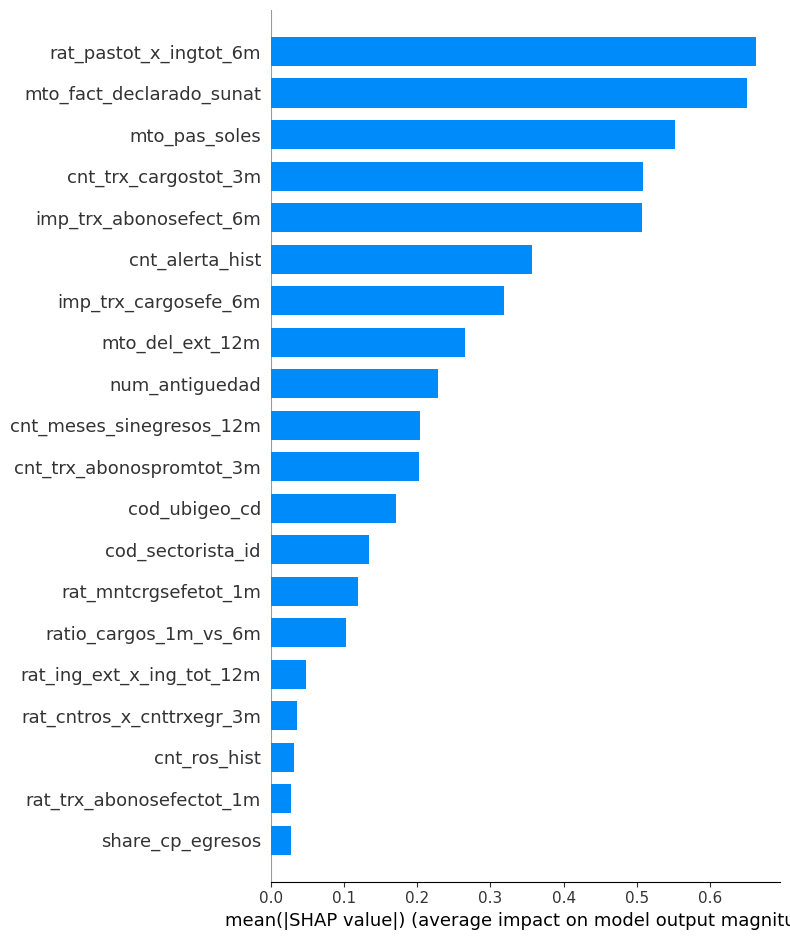

In [65]:
import shap
import pandas as pd
import numpy as np

# ===============================
# Dataset de referencia (ej: 202508)
# ===============================
df_ref = df_test[
    (df_test.cod_mes == 202508) 
    #&(df_test.tipo_alerta_n2 != '0')
].copy()

cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']
X_ref = df_ref.drop(columns=cols_excluir, errors='ignore')

# SHAP explainer (XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ref)

# Summary plot
shap.summary_plot(shap_values, X_ref, plot_type="bar")


In [66]:
variable_names = X_test.columns
# Calcula la magnitud promedio de los valores SHAP para cada variable
average_shap_values = np.abs(shap_values).mean(axis=0)

# Crea una lista de tuplas (variable, importancia, valor_absoluto)
variable_importance = [(variable_name, importance, abs_value) for variable_name, importance, abs_value in zip(variable_names, average_shap_values, shap_values.mean(axis=0))]

# Ordena la lista de importancia de mayor a menor
variable_importance.sort(key=lambda x: x[1], reverse=True)

# Obtén las variables más importantes junto con sus importancias y valores absolutos
variables_mas_importantes = [(variable[0], variable[1], variable[2]) for variable in variable_importance]

In [67]:
import csv

# Nombre del archivo CSV de salida
output_csv = 'importancia_variables.csv'

# Escribe los datos en el archivo CSV
with open(output_csv, 'w', newline='') as csvfile:
    
    # Define el escritor CSV
    csv_writer = csv.writer(csvfile)
    
    # Escribe el encabezado
    csv_writer.writerow(['Variable', 'Importancia', 'Valor Absoluto SHAP'])
    
    # Escribe los datos de cada variable
    for variable in variables_mas_importantes:
        csv_writer.writerow([variable[0], variable[1], variable[2]])


In [68]:
variables_mas_importantes

[('rat_pastot_x_ingtot_6m', np.float32(0.6620012), np.float32(-0.37739804)),
 ('mto_fact_declarado_sunat', np.float32(0.6503903), np.float32(-0.4796663)),
 ('mto_pas_soles', np.float32(0.5515882), np.float32(-0.35750833)),
 ('cnt_trx_cargostot_3m', np.float32(0.5080988), np.float32(-0.40517455)),
 ('imp_trx_abonosefect_6m', np.float32(0.50723076), np.float32(-0.44454706)),
 ('cnt_alerta_hist', np.float32(0.35607478), np.float32(-0.25740096)),
 ('imp_trx_cargosefe_6m', np.float32(0.31891456), np.float32(-0.2504466)),
 ('mto_del_ext_12m', np.float32(0.2653201), np.float32(-0.25013897)),
 ('num_antiguedad', np.float32(0.22907783), np.float32(-0.13734435)),
 ('cnt_meses_sinegresos_12m', np.float32(0.2037564), np.float32(-0.08155555)),
 ('cnt_trx_abonospromtot_3m',
  np.float32(0.20248437),
  np.float32(-0.014913195)),
 ('cod_ubigeo_cd', np.float32(0.17080948), np.float32(-0.108468585)),
 ('cod_sectorista_id', np.float32(0.13392287), np.float32(-0.08682539)),
 ('rat_mntcrgsefetot_1m', np.fl

In [ ]:

# ============================================================
# PRECISIÓN TOP20% y RECALL TOP20% — Train / Validation / Test
# Universo completo (todos los registros, no solo alertas)
# Ref: §13.4, §13.5, §13.6 DOCUMENTO_METODOLOGICO v2.1
# ============================================================

import pandas as pd
import numpy as np
import xgboost as xgb

PERIODOS_TRAIN = [202501, 202502, 202503, 202504, 202505, 202506, 202507]
PERIODOS_VAL   = [202508, 202509]
PERIODOS_TEST  = [202510, 202511, 202512, 202601, 202602, 202603, 202604]

COLS_EXCLUIR = ['key_value', 'cod_mes', 'cod_cli', 'tipo_alerta_n2',
                'trx_riesgo_cliente', 'target']

def _predecir(df_subset, modelo):
    X = df_subset.drop(columns=COLS_EXCLUIR, errors='ignore')
    dm = xgb.DMatrix(X, enable_categorical=True)
    return modelo.predict(dm)

def metricas_top_pct(df, prob_col, target_col, pct=0.20):
    """
    Calcula Precisión y Recall sobre el top `pct`% de registros por score.
    """
    df = df.sort_values(prob_col, ascending=False).reset_index(drop=True)
    k = max(1, int(np.ceil(len(df) * pct)))
    top = df.head(k)
    tp              = int(top[target_col].sum())
    total_positivos = int(df[target_col].sum())
    precision       = round(tp / k, 6) if k > 0 else 0.0
    recall          = round(tp / total_positivos, 6) if total_positivos > 0 else 0.0
    return {
        "n_total"        : len(df),
        "k_top20pct"     : k,
        "total_positivos": total_positivos,
        "tp_top20pct"    : tp,
        "precision_top20": round(precision * 100, 2),   # en %
        "recall_top20"   : round(recall    * 100, 2),   # en %
        "lift_top20"     : round(precision / (total_positivos / len(df)), 2)
                           if total_positivos > 0 else None,
    }

# ── Calcular por mes para cada conjunto ─────────────────────────────────────
def calcular_conjunto(df_base, periodos, nombre_conjunto):
    filas = []
    for mes in periodos:
        sub = df_base[df_base['cod_mes'] == float(mes)].copy()
        if sub.empty or sub['target'].sum() == 0:
            continue
        sub['prob'] = _predecir(sub, model)
        m = metricas_top_pct(sub, 'prob', 'target', pct=0.20)
        m['mes']       = mes
        m['conjunto']  = nombre_conjunto
        filas.append(m)
    return filas

filas_train = calcular_conjunto(df_train, PERIODOS_TRAIN, 'TRAIN')
filas_val   = calcular_conjunto(df_val,   PERIODOS_VAL,   'VALIDATION')
filas_test  = calcular_conjunto(df_test,  PERIODOS_TEST,  'TEST')

df_top20 = pd.DataFrame(filas_train + filas_val + filas_test)
df_top20 = df_top20[['conjunto','mes','n_total','total_positivos',
                      'k_top20pct','tp_top20pct',
                      'precision_top20','recall_top20','lift_top20']]

print("=" * 75)
print("PRECISIÓN TOP20% y RECALL TOP20% — universo completo")
print("=" * 75)
print(df_top20.to_string(index=False))

# ── Resumen por conjunto (promedio) ─────────────────────────────────────────
resumen = (
    df_top20.groupby('conjunto')[['precision_top20','recall_top20','lift_top20']]
    .mean()
    .round(2)
    .reindex(['TRAIN','VALIDATION','TEST'])
    .reset_index()
)
print()
print("RESUMEN PROMEDIO POR CONJUNTO:")
print(resumen.to_string(index=False))
print()
print("▶ Copiar a §13.4 (Train), §13.5 (Validation), §13.6 (Test) del documento v2.1")
